# Single-Cell Pairing Graph Analysis

This notebook builds clonotype pairing graphs for four 10x samples and compares three stages: raw parsed tables, imputed missing-chain tables, and cleaned tables.

In [13]:
# Shared imports and runtime helper.
import importlib
import sys
import time
from pathlib import Path

import igraph as ig
import matplotlib.pyplot as plt
import polars as pl

repo_root = (Path.cwd() / "..").resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from mir.common.single_cell import build_tenx_sample_from_cell_clonotypes, load_10x_vdj_v1_sample
from mir.common.single_cell_parser import load_10x_vdj_v1_cell_clonotypes
import mir.common.single_cell_repair as single_cell_repair
from mir.graph.single_cell_pairing import build_pairing_graph

single_cell_repair = importlib.reload(single_cell_repair)
cleanup_cell_clonotypes = single_cell_repair.cleanup_cell_clonotypes
impute_missing_chains = single_cell_repair.impute_missing_chains

SEED = 42


def run_step(name, fn, *args, **kwargs):
    # Keep per-step timing visible for long-running sample loops.
    t0 = time.perf_counter()
    result = fn(*args, **kwargs)
    dt = time.perf_counter() - t0
    print(f"{name}: {dt:.2f}s")
    return result

print(f"cwd: {Path.cwd()}")
print(f"repo_root: {repo_root}")
print(f"seed: {SEED}")

cwd: /Users/mikesh/vcs/mirpy/notebooks
repo_root: /Users/mikesh/vcs/mirpy
seed: 42


## Load Sample Inputs

Discover sample annotation file pairs and preview parsed rows.

In [14]:
# Resolve sample input files and validate the parsed schema.
cwd = Path.cwd()
repo_root = cwd if (cwd / "mir").exists() else cwd.parent
base = repo_root / "notebooks" / "assets" / "large" / "airr_benchmark" / "dcode"

pairs = []
for all_contig in sorted(base.glob("*_all_contig_annotations.csv.gz")):
    consensus = base / all_contig.name.replace("_all_contig_annotations", "_consensus_annotations")
    if consensus.exists():
        sample_id = all_contig.name.split("_all_contig_annotations")[0]
        pairs.append((sample_id, consensus, all_contig))

print(f"samples found: {len(pairs)}")
for sample_id, _, _ in pairs[:4]:
    print(" -", sample_id)

if not pairs:
    raise RuntimeError(f"No sample pairs found under {base}")

first = pairs[0]
first_df = run_step(
    "load_cell_table_preview",
    load_10x_vdj_v1_cell_clonotypes,
    first[1],
    first[2],
    sample_id=first[0],
)
print(first_df.select(["barcode", "raw_pair_id", "sequence_id", "locus"]).head(5))

samples found: 4
 - vdj_v1_hs_aggregated_donor1
 - vdj_v1_hs_aggregated_donor2
 - vdj_v1_hs_aggregated_donor3
 - vdj_v1_hs_aggregated_donor4
load_cell_table_preview: 0.50s
shape: (5, 4)
┌─────────────────────┬───────────────┬───────────────────────────┬───────┐
│ barcode             ┆ raw_pair_id   ┆ sequence_id               ┆ locus │
│ ---                 ┆ ---           ┆ ---                       ┆ ---   │
│ str                 ┆ str           ┆ str                       ┆ str   │
╞═════════════════════╪═══════════════╪═══════════════════════════╪═══════╡
│ AAACCTGAGACAAAGG-4  ┆ clonotype19   ┆ clonotype19_consensus_1   ┆ TRB   │
│ AAACCTGAGACAAAGG-4  ┆ clonotype19   ┆ clonotype19_consensus_2   ┆ TRA   │
│ AAACCTGAGACAAAGG-4  ┆ clonotype19   ┆ clonotype19_consensus_3   ┆ TRA   │
│ AAACCTGAGACTGTAA-34 ┆ clonotype1318 ┆ clonotype1318_consensus_1 ┆ TRB   │
│ AAACCTGAGAGCCCAA-5  ┆ clonotype1319 ┆ clonotype1319_consensus_2 ┆ TRA   │
└─────────────────────┴───────────────┴───────────────

## Parser vs Loader Consistency

Validate parser-first assembly and direct loader produce matching counts.

In [15]:
# Build sample object from parsed table and compare to direct loader shape.
sample_id, cp, ap = pairs[0]
cell_table = run_step(
    "parse_cell_table",
    load_10x_vdj_v1_cell_clonotypes,
    cp,
    ap,
    sample_id=sample_id,
)
parsed_sample = build_tenx_sample_from_cell_clonotypes(cell_table, sample_id=sample_id)
direct_sample = run_step("direct_loader", load_10x_vdj_v1_sample, cp, ap, sample_id=sample_id)

print("parsed sample cells:", parsed_sample.loaded_cell_count)
print("direct sample cells:", direct_sample.loaded_cell_count)
print("parsed sample clonotypes:", parsed_sample.loaded_clonotype_count)
print("direct sample clonotypes:", direct_sample.loaded_clonotype_count)

parse_cell_table: 0.49s
direct_loader: 1.21s
parsed sample cells: 47271
direct sample cells: 47271
parsed sample clonotypes: 61298
direct sample clonotypes: 61298


## Build Raw, Imputed, and Cleanup Graphs

Compute stage summaries, impute/cleanup runtimes, and TRA/TRB contingency tables for each sample.

In [16]:
# Build per-sample stage outputs, timing metrics, and TRA/TRB contingency tables.
CHAIN_COLORS = {
    "TRA": "#1f77b4",
    "TRB": "#ff7f0e",
    "TRG": "#2ca02c",
    "TRD": "#d62728",
    "IGH": "#9467bd",
    "IGK": "#8c564b",
    "IGL": "#e377c2",
}


def tra_trb_contingency(sample):
    m = sample.chain_multiplicity.filter(pl.col("locus_pair") == "TRA_TRB")
    if m.height == 0:
        return pl.DataFrame({"tra": [], "trb": [], "cell_count": []})
    return (
        m.with_columns(
            pl.when(pl.col("n_chain1") > 0).then(pl.lit("TRA+")).otherwise(pl.lit("TRA-")).alias("tra"),
            pl.when(pl.col("m_chain2") > 0).then(pl.lit("TRB+")).otherwise(pl.lit("TRB-")).alias("trb"),
        )
        .group_by(["tra", "trb"])
        .agg(pl.sum("cell_count").alias("cell_count"))
        .sort(["tra", "trb"])
    )


stage_results = {}
summary_rows = []
contingency_rows = []

for sample_id, cp, ap in pairs[:4]:
    raw = run_step(
        f"raw_parse_{sample_id}",
        load_10x_vdj_v1_cell_clonotypes,
        cp,
        ap,
        sample_id=sample_id,
    )

    t_impute_start = time.perf_counter()
    imputed = impute_missing_chains(raw, seed=SEED, reuse_slave_per_master=True)
    t_impute = time.perf_counter() - t_impute_start

    t_cleanup_start = time.perf_counter()
    cleaned = cleanup_cell_clonotypes(
        imputed,
        enforce_consistent_slave_per_master=True,
        consistency_only_on_synthetic_slave=True,
        max_slave_edges_per_master=10,
    )
    t_cleanup = time.perf_counter() - t_cleanup_start

    raw_sample = build_tenx_sample_from_cell_clonotypes(raw, sample_id=sample_id)
    imp_sample = build_tenx_sample_from_cell_clonotypes(imputed, sample_id=sample_id)
    cln_sample = build_tenx_sample_from_cell_clonotypes(cleaned, sample_id=sample_id)

    raw_graph = build_pairing_graph(raw_sample)
    imp_graph = build_pairing_graph(imp_sample)
    cln_graph = build_pairing_graph(cln_sample)

    stage_results[sample_id] = {
        "raw": raw_graph,
        "imputed": imp_graph,
        "cleanup": cln_graph,
    }

    for stage, table, sample in [
        ("raw", raw, raw_sample),
        ("imputed", imputed, imp_sample),
        ("cleanup", cleaned, cln_sample),
    ]:
        graph = stage_results[sample_id][stage]
        summary_rows.append(
            {
                "sample_id": sample_id,
                "stage": stage,
                "cell_rows": table.height,
                "nodes": graph.nodes.height,
                "edges": graph.edges.height,
                "impute_seconds": t_impute if stage == "imputed" else None,
                "cleanup_seconds": t_cleanup if stage == "cleanup" else None,
            }
        )

        cont = tra_trb_contingency(sample)
        for r in cont.iter_rows(named=True):
            contingency_rows.append(
                {
                    "sample_id": sample_id,
                    "stage": stage,
                    "tra": r["tra"],
                    "trb": r["trb"],
                    "cell_count": int(r["cell_count"]),
                }
            )

summary_df = pl.DataFrame(summary_rows).sort(["sample_id", "stage"])
contingency_df = pl.DataFrame(contingency_rows).sort(["sample_id", "stage", "tra", "trb"])

print("Stage summary:")
display(summary_df)
print("TRA/TRB contingency by stage:")
display(contingency_df)

raw_parse_vdj_v1_hs_aggregated_donor1: 0.78s
raw_parse_vdj_v1_hs_aggregated_donor2: 0.63s
raw_parse_vdj_v1_hs_aggregated_donor3: 0.54s
raw_parse_vdj_v1_hs_aggregated_donor4: 0.42s
Stage summary:


sample_id,stage,cell_rows,nodes,edges,impute_seconds,cleanup_seconds
str,str,i64,i64,i64,f64,f64
"""vdj_v1_hs_aggregated_donor1""","""cleanup""",100250,64088,33787,null,0.464816
"""vdj_v1_hs_aggregated_donor1""","""imputed""",102610,66280,36773,16.670889,null
"""vdj_v1_hs_aggregated_donor1""","""raw""",95663,56312,31458,null,null
"""vdj_v1_hs_aggregated_donor2""","""cleanup""",163532,44380,23774,null,0.702729
"""vdj_v1_hs_aggregated_donor2""","""imputed""",168351,47658,28100,22.142734,null
…,…,…,…,…,…,…
"""vdj_v1_hs_aggregated_donor3""","""imputed""",81080,40583,23223,10.9166,null
"""vdj_v1_hs_aggregated_donor3""","""raw""",77033,35411,20259,null,null
"""vdj_v1_hs_aggregated_donor4""","""cleanup""",57493,34749,18505,null,0.26055


TRA/TRB contingency by stage:


sample_id,stage,tra,trb,cell_count
str,str,str,str,i64
"""vdj_v1_hs_aggregated_donor1""","""cleanup""","""TRA+""","""TRB+""",47271
"""vdj_v1_hs_aggregated_donor1""","""imputed""","""TRA+""","""TRB+""",47271
"""vdj_v1_hs_aggregated_donor1""","""raw""","""TRA+""","""TRB+""",40324
"""vdj_v1_hs_aggregated_donor1""","""raw""","""TRA+""","""TRB-""",1380
"""vdj_v1_hs_aggregated_donor1""","""raw""","""TRA-""","""TRB+""",5567
…,…,…,…,…
"""vdj_v1_hs_aggregated_donor4""","""cleanup""","""TRA+""","""TRB+""",27640
"""vdj_v1_hs_aggregated_donor4""","""imputed""","""TRA+""","""TRB+""",27640
"""vdj_v1_hs_aggregated_donor4""","""raw""","""TRA+""","""TRB+""",25127


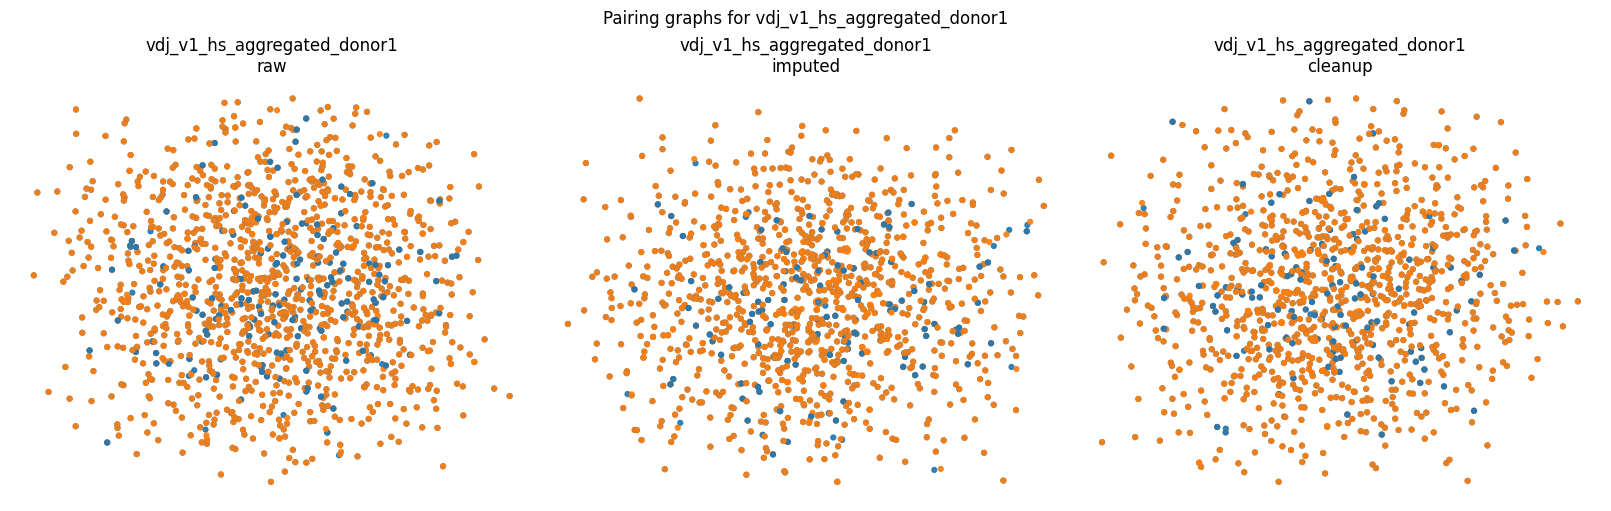

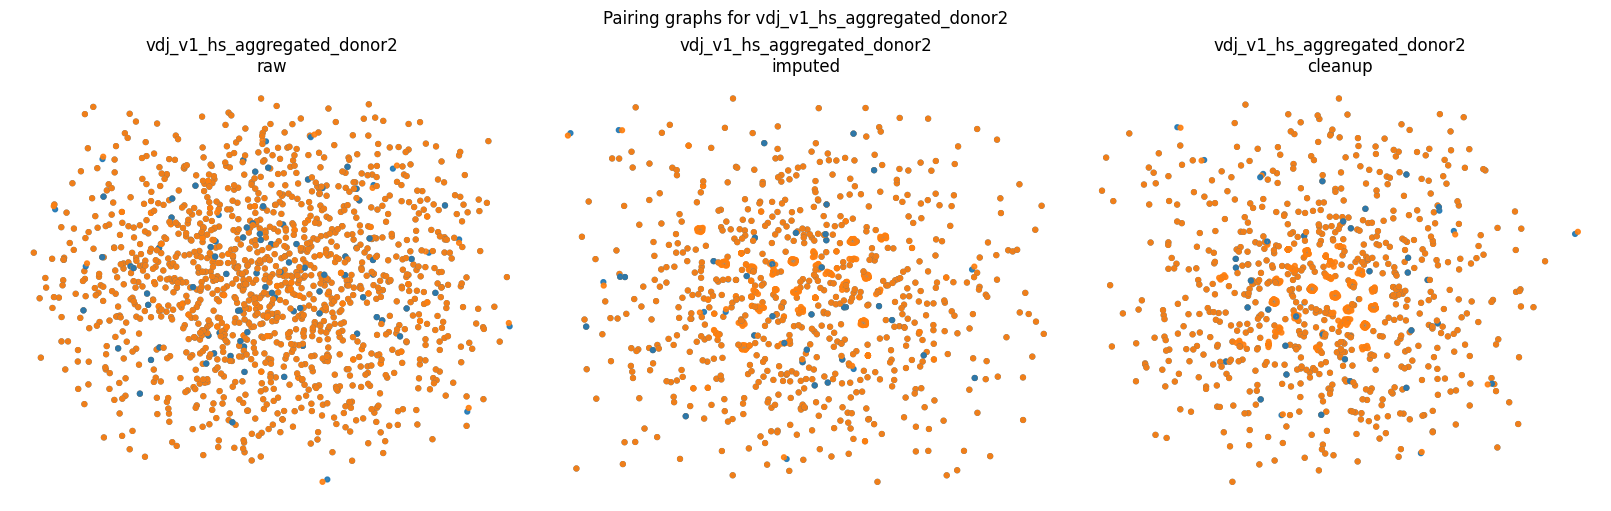

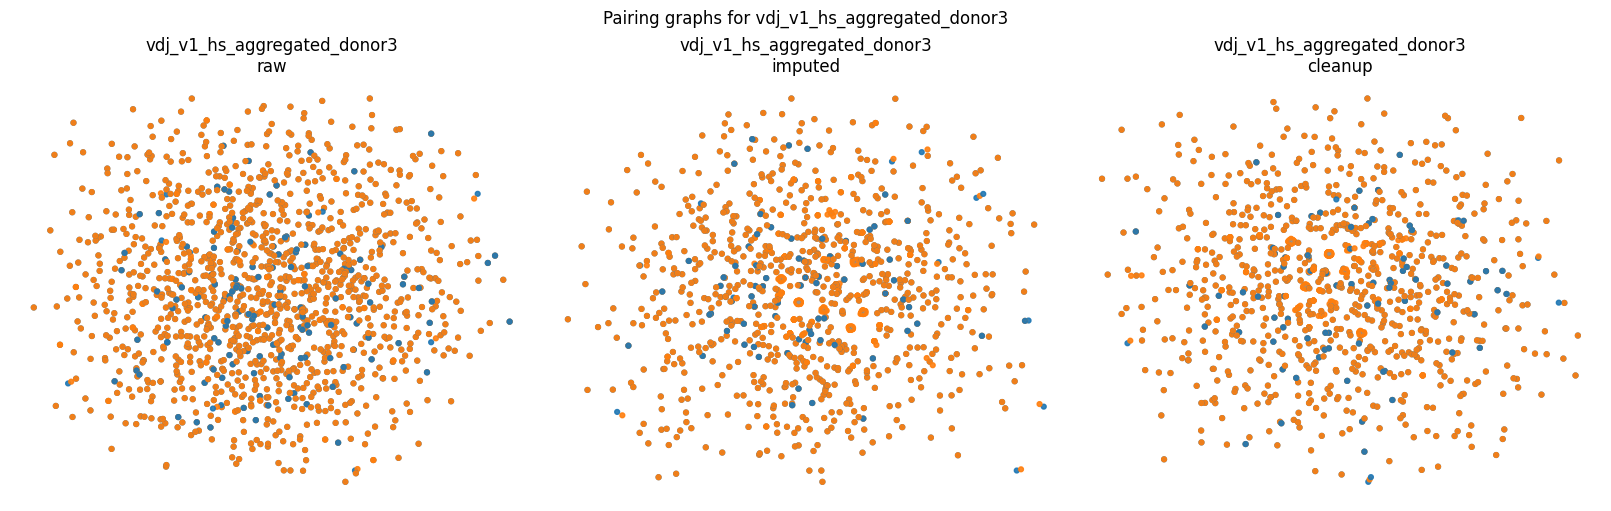

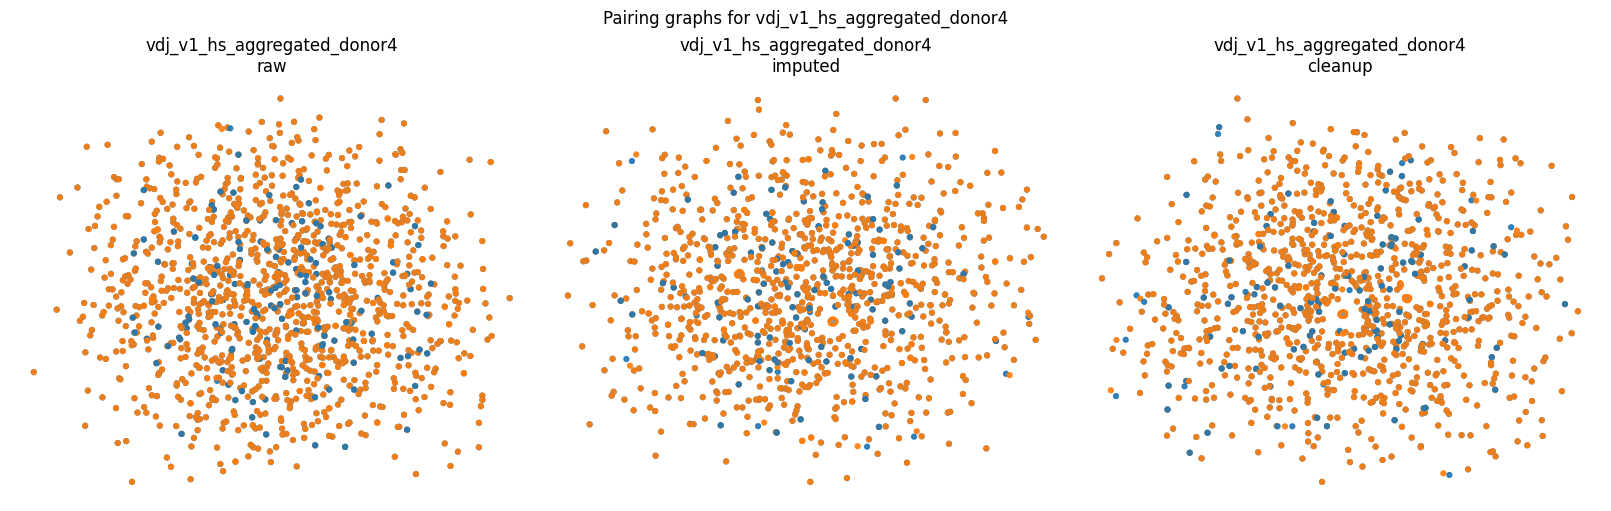

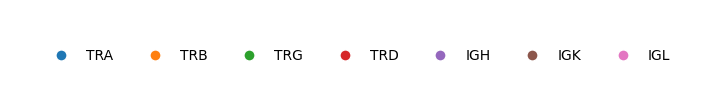

In [17]:
# Plot graph panels for each sample and stage with igraph (bounded size for speed and readability).
def _igraph_from_pairing_graph(pairing_graph, *, max_edges=1500):
    edges_df = pairing_graph.edges.sort("cell_count", descending=True).head(max_edges)
    edge_rows = edges_df.to_dicts()
    edge_nodes = set()
    for row in edge_rows:
        edge_nodes.add(row["source"])
        edge_nodes.add(row["target"])

    nodes_df = pairing_graph.nodes.filter(pl.col("node_id").is_in(list(edge_nodes)))
    node_rows = nodes_df.to_dicts()

    name_to_idx = {row["node_id"]: idx for idx, row in enumerate(node_rows)}
    edges = [(name_to_idx[row["source"]], name_to_idx[row["target"]]) for row in edge_rows]
    weights = [max(1, int(row["cell_count"])) for row in edge_rows]

    g = ig.Graph(n=len(node_rows), edges=edges, directed=False)
    g.vs["name"] = [row["node_id"] for row in node_rows]
    g.vs["locus"] = [row["locus"] for row in node_rows]
    g.vs["color"] = [CHAIN_COLORS.get(row["locus"], "#7f7f7f") for row in node_rows]
    g.es["weight"] = weights
    return g


def _plot_igraph(ax, g, title):
    if g.vcount() == 0:
        ax.set_title(f"{title} (empty)")
        ax.axis("off")
        return

    layout = g.layout_fruchterman_reingold(weights=g.es["weight"], niter=1200)
    xs = [p[0] for p in layout]
    ys = [p[1] for p in layout]

    max_w = max(g.es["weight"]) if g.ecount() > 0 else 1
    for e in g.es:
        s, t = e.tuple
        # Log-scaled widths keep heavy edges visible without saturating the plot.
        width = 0.2 + 1.4 * (float(e["weight"]) / float(max_w)) ** 0.5
        ax.plot(
            [xs[s], xs[t]],
            [ys[s], ys[t]],
            color="#9a9a9a",
            alpha=0.18,
            linewidth=width,
        )

    ax.scatter(xs, ys, c=g.vs["color"], s=12, alpha=0.9)
    ax.set_title(title)
    ax.axis("off")


for sample_id in sorted(stage_results):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
    for ax, stage in zip(axes, ["raw", "imputed", "cleanup"]):
        ig_graph = _igraph_from_pairing_graph(stage_results[sample_id][stage])
        _plot_igraph(ax, ig_graph, f"{sample_id}\n{stage}")
    fig.suptitle(f"Pairing graphs for {sample_id}")
    plt.show()

legend_handles = [
    plt.Line2D([0], [0], marker="o", color="w", label=locus, markerfacecolor=color, markersize=8)
    for locus, color in CHAIN_COLORS.items()
]
fig, ax = plt.subplots(figsize=(9, 1.2))
ax.legend(handles=legend_handles, ncol=7, loc="center", frameon=False)
ax.axis("off")
plt.show()

## Test Command

Run focused single-cell tests from repository root.

In [19]:
# Print reproducible validation commands.
print("Run in terminal from repo root:")
print("python -m pytest tests/test_single_cell.py tests/test_single_cell_repair.py -q")
print("env RUN_BENCHMARK=1 python -m pytest tests/test_single_cell_repair_benchmark.py -s -x")

Run in terminal from repo root:
python -m pytest tests/test_single_cell.py tests/test_single_cell_repair.py -q
env RUN_BENCHMARK=1 python -m pytest tests/test_single_cell_repair_benchmark.py -s -x


## Notes

Graph plotting below uses igraph with bounded node/edge subsets per sample-stage to keep layout runtime predictable.